# Superstore EDA — Final Portfolio Notebook

**Case:** Superstore Retail Transactions  
**Notebook purpose:** audit-ready exploratory analysis for a retail sales dataset  
**Lifecycle alignment:** ASK → PREPARE → PROCESS → ANALYZE

## Notebook rules
- Validate before analyzing
- Do not overclaim causality
- Keep all transformations explicit
- Record assumptions, limitations, and validation checks

## 1. Analytical objective

This notebook is designed to answer the following non-causal business questions:

1. Which categories, sub-categories, regions, and customer segments contribute most to sales and profit?
2. Where are the main negative-profit patterns concentrated?
3. How are discounting, sales, and profitability associated at a descriptive level?

## Scope
- Descriptive and exploratory analysis only
- No forecasting
- No causal inference
- No recommendation inflation beyond the evidence

## Assumptions
- Each row represents one order line
- `Row ID` is intended to be unique
- `Sales`, `Quantity`, `Discount`, and `Profit` are transaction-level measures
- `Order Date` and `Ship Date` are parseable dates

## Limitations
- This is a static dataset, not a live retail system
- Results depend on dataset quality and may not generalize to other retailers
- Associations in this notebook do not establish business causality

## 2. Environment setup

In [95]:
# --- Environment Setup ---
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display Settings ---
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- Reproducibility ---
RANDOM_STATE = 42

# --- Project Paths ---
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Sample - Superstore.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Expected data path: {DATA_PATH}")

Project root: c:\Users\Lazarus\Github\data-analysis-lab
Expected data path: c:\Users\Lazarus\Github\data-analysis-lab\data\raw\Sample - Superstore.csv


## 3. Data load

In [96]:
# --- Data Load (Validated) ---
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"\nDataset not found at:\n{DATA_PATH}\n\n"
        "Fix options:\n"
        "1. Move file to data/raw/\n"
        "2. Or update DATA_PATH\n"
    )

df = pd.read_csv(DATA_PATH, encoding="latin1")

print(f"Loaded dataset successfully")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded dataset successfully
Shape: 9,994 rows × 21 columns


## 4. PREPARE — structural validation

This section documents the raw dataset structure without changing the data.

In [97]:
prepare_summary = {
    "row_count": len(df),
    "column_count": df.shape[1],
    "columns": df.columns.tolist()
}
prepare_summary

{'row_count': 9994,
 'column_count': 21,
 'columns': ['Row ID',
  'Order ID',
  'Order Date',
  'Ship Date',
  'Ship Mode',
  'Customer ID',
  'Customer Name',
  'Segment',
  'Country',
  'City',
  'State',
  'Postal Code',
  'Region',
  'Product ID',
  'Category',
  'Sub-Category',
  'Product Name',
  'Sales',
  'Quantity',
  'Discount',
  'Profit']}

In [98]:
schema_df = pd.DataFrame({
    "column": df.columns,
    "observed_dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "null_pct": ((df.isna().sum() / len(df)) * 100).round(2).values,
    "n_unique": df.nunique(dropna=False).values
}).sort_values(["null_pct", "column"], ascending=[False, True])

schema_df

,column,observed_dtype,non_null_count,null_count,null_pct,n_unique
14,Category,str,9994,0,0.00,3
9,City,str,9994,0,0.00,531
8,Country,str,9994,0,0.00,1
5,Customer ID,str,9994,0,0.00,793
6,Customer Name,str,9994,0,0.00,793
19,Discount,float64,9994,0,0.00,12
2,Order Date,str,9994,0,0.00,1237
1,Order ID,str,9994,0,0.00,5009
11,Postal Code,int64,9994,0,0.00,631
13,Product ID,str,9994,0,0.00,1862


In [99]:
print("Sample rows:")
display(df.sample(5, random_state=RANDOM_STATE))

Sample rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3125,3126,CA-2015-121720,6/11/2015,6/12/2015,First Class,JE-15610,Jim Epp,Corporate,United States,Lakeland,Florida,33801,South,OFF-ST-10003816,Office Supplies,Storage,Fellowes High-Stak Drawer Files,563.81,4,0.20,21.14
1441,1442,CA-2017-128160,12/19/2017,12/24/2017,Second Class,MM-17920,Michael Moore,Consumer,United States,San Francisco,California,94110,West,OFF-BI-10001510,Office Supplies,Binders,Deluxe Heavy-Duty Vinyl Round Ring Binder,36.67,2,0.20,11.46
4510,4511,CA-2016-119935,11/10/2016,11/14/2016,Standard Class,KM-16225,Kalyca Meade,Corporate,United States,Springfield,Missouri,65807,Central,FUR-FU-10001085,Furniture,Furnishings,3M Polarizing Light Filter Sleeves,37.30,2,0.00,17.16
39,40,CA-2015-117415,12/27/2015,12/31/2015,Standard Class,SN-20710,Steve Nguyen,Home Office,United States,Houston,Texas,77041,Central,FUR-CH-10004218,Furniture,Chairs,"Global Fabric Manager's Chair, Dark Gray",212.06,3,0.30,-15.15
4509,4510,CA-2017-167003,5/23/2017,5/29/2017,Standard Class,VS-21820,Vivek Sundaresam,Consumer,United States,Los Angeles,California,90036,West,FUR-TA-10001520,Furniture,Tables,"Lesro Sheffield Collection Coffee Table, End T...",171.29,3,0.20,-6.42


### 4.1 Grain and key checks

In [100]:
candidate_key_checks = {
    "row_id_unique": df["Row ID"].is_unique,
    "duplicate_full_rows": int(df.duplicated().sum()),
    "duplicate_row_id": int(df["Row ID"].duplicated().sum()),
    "duplicate_order_product_pairs": int(df.duplicated(subset=["Order ID", "Product ID"]).sum())
}
candidate_key_checks

{'row_id_unique': True,
 'duplicate_full_rows': 0,
 'duplicate_row_id': 0,
 'duplicate_order_product_pairs': 8}

### 4.2 Missingness profile

In [69]:
missing_df = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().sum() / len(df) * 100).round(2)
    })
    .sort_values(["missing_pct", "missing_count"], ascending=False)
)

missing_df[missing_df["missing_count"] > 0]

,missing_count,missing_pct


### 4.3 Type and range validation

In [70]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]
range_checks = {
    "negative_sales_count": int((df["Sales"] < 0).sum()),
    "non_positive_quantity_count": int((df["Quantity"] <= 0).sum()),
    "discount_below_zero_count": int((df["Discount"] < 0).sum()),
    "discount_above_one_count": int((df["Discount"] > 1).sum()),
    "negative_profit_count": int((df["Profit"] < 0).sum()),
}
range_checks

{'negative_sales_count': 0,
 'non_positive_quantity_count': 0,
 'discount_below_zero_count': 0,
 'discount_above_one_count': 0,
 'negative_profit_count': 1871}

In [71]:
df["Order Date Parsed"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date Parsed"] = pd.to_datetime(df["Ship Date"], errors="coerce")

date_checks = {
    "invalid_order_date_count": int(df["Order Date Parsed"].isna().sum()),
    "invalid_ship_date_count": int(df["Ship Date Parsed"].isna().sum()),
    "ship_before_order_count": int((df["Ship Date Parsed"] < df["Order Date Parsed"]).sum()),
    "min_order_date": df["Order Date Parsed"].min(),
    "max_order_date": df["Order Date Parsed"].max(),
}
date_checks

{'invalid_order_date_count': 0,
 'invalid_ship_date_count': 0,
 'ship_before_order_count': 0,
 'min_order_date': Timestamp('2014-01-03 00:00:00'),
 'max_order_date': Timestamp('2017-12-30 00:00:00')}

In [72]:
categorical_scan = {
    "segments": sorted(df["Segment"].dropna().unique().tolist()),
    "regions": sorted(df["Region"].dropna().unique().tolist()),
    "categories": sorted(df["Category"].dropna().unique().tolist()),
    "ship_modes": sorted(df["Ship Mode"].dropna().unique().tolist())
}
categorical_scan

{'segments': ['Consumer', 'Corporate', 'Home Office'],
 'regions': ['Central', 'East', 'South', 'West'],
 'categories': ['Furniture', 'Office Supplies', 'Technology'],
 'ship_modes': ['First Class', 'Same Day', 'Second Class', 'Standard Class']}

### 4.4 PREPARE validation summary

In [73]:
prepare_validation = pd.DataFrame([
    ["Row count confirmed", True],
    ["Column count confirmed", True],
    ["Schema documented", True],
    ["Missingness profiled", True],
    ["Duplicate checks performed", True],
    ["Range checks performed", True],
    ["Date parsing checks performed", True],
    ["No transformations applied to core business fields yet", True],
], columns=["check", "status"])

prepare_validation

,check,status
0,Row count confirmed,True
1,Column count confirmed,True
2,Schema documented,True
3,Missingness profiled,True
4,Duplicate checks performed,True
5,Range checks performed,True
6,Date parsing checks performed,True
7,No transformations applied to core business fi...,True


## 5. PROCESS — explicit cleaning and feature engineering

Only minimal, transparent changes are applied here.  
Raw business columns are preserved where practical.

In [74]:
df_clean = df.copy()

# Preserve parsed dates as analysis-ready fields
df_clean = df_clean.rename(columns={
    "Order Date Parsed": "order_date",
    "Ship Date Parsed": "ship_date"
})

# Standardized helper columns
df_clean["year"] = df_clean["order_date"].dt.year
df_clean["month"] = df_clean["order_date"].dt.to_period("M").astype(str)
df_clean["ship_delay_days"] = (df_clean["ship_date"] - df_clean["order_date"]).dt.days

processing_log = pd.DataFrame([
    ["Create parsed order date", "Order Date -> order_date", "Supports temporal validation and analysis"],
    ["Create parsed ship date", "Ship Date -> ship_date", "Supports shipping lag validation and analysis"],
    ["Create year", "order_date.dt.year", "Supports yearly aggregation"],
    ["Create month", "order_date.dt.to_period('M')", "Supports monthly aggregation"],
    ["Create ship delay", "ship_date - order_date", "Supports fulfillment descriptives"],
], columns=["step", "change", "rationale"])

processing_log

,step,change,rationale
0,Create parsed order date,Order Date -> order_date,Supports temporal validation and analysis
1,Create parsed ship date,Ship Date -> ship_date,Supports shipping lag validation and analysis
2,Create year,order_date.dt.year,Supports yearly aggregation
3,Create month,order_date.dt.to_period('M'),Supports monthly aggregation
4,Create ship delay,ship_date - order_date,Supports fulfillment descriptives


In [75]:
process_validation = {
    "row_count_before": len(df),
    "row_count_after": len(df_clean),
    "column_count_before": df.shape[1],
    "column_count_after": df_clean.shape[1],
    "rows_removed": len(df) - len(df_clean),
    "remaining_invalid_order_dates": int(df_clean["order_date"].isna().sum()),
    "remaining_invalid_ship_dates": int(df_clean["ship_date"].isna().sum()),
}
process_validation

{'row_count_before': 9994,
 'row_count_after': 9994,
 'column_count_before': 23,
 'column_count_after': 26,
 'rows_removed': 0,
 'remaining_invalid_order_dates': 0,
 'remaining_invalid_ship_dates': 0}

## 6. ANALYZE — overview metrics

In [76]:
overview = pd.DataFrame({
    "metric": [
        "Orders (unique)",
        "Customers (unique)",
        "Products (unique)",
        "Total Sales",
        "Total Profit",
        "Average Sales per Row",
        "Average Profit per Row",
        "Negative Profit Rows",
        "Average Discount",
        "Median Ship Delay (days)"
    ],
    "value": [
        df_clean["Order ID"].nunique(),
        df_clean["Customer ID"].nunique(),
        df_clean["Product ID"].nunique(),
        df_clean["Sales"].sum(),
        df_clean["Profit"].sum(),
        df_clean["Sales"].mean(),
        df_clean["Profit"].mean(),
        (df_clean["Profit"] < 0).sum(),
        df_clean["Discount"].mean(),
        df_clean["ship_delay_days"].median()
    ]
})

overview

,metric,value
0,Orders (unique),"5,009.00"
1,Customers (unique),793.00
2,Products (unique),"1,862.00"
3,Total Sales,"2,297,200.86"
4,Total Profit,"286,397.02"
5,Average Sales per Row,229.86
6,Average Profit per Row,28.66
7,Negative Profit Rows,"1,871.00"
8,Average Discount,0.16
9,Median Ship Delay (days),4.00


## 7. Sales and profit by category

In [77]:
category_perf = (
    df_clean.groupby("Category", as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        orders=("Order ID", "nunique"),
        avg_discount=("Discount", "mean")
    )
    .sort_values("sales", ascending=False)
)

category_perf

,Category,sales,profit,orders,avg_discount
2,Technology,"836,154.03","145,454.95",1544,0.13
0,Furniture,"741,999.80","18,451.27",1764,0.17
1,Office Supplies,"719,047.03","122,490.80",3742,0.16


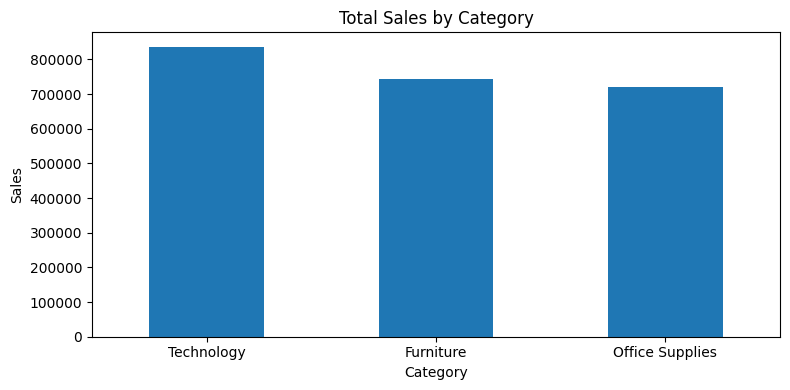

In [78]:
ax = category_perf.plot(
    x="Category",
    y="sales",
    kind="bar",
    legend=False,
    figsize=(8, 4),
    title="Total Sales by Category",
    rot=0
)
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

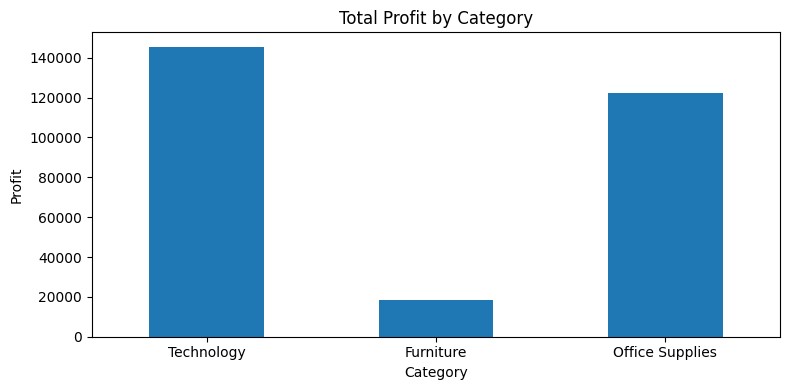

In [79]:
ax = category_perf.plot(
    x="Category",
    y="profit",
    kind="bar",
    legend=False,
    figsize=(8, 4),
    title="Total Profit by Category",
    rot=0
)
ax.set_ylabel("Profit")
plt.tight_layout()
plt.show()

## 8. Top Contributors (Pareto Analysis)

In [80]:
subcat_sales_pareto = (
    df_clean.groupby("Sub-Category", as_index=False)
    .agg(sales=("Sales", "sum"))
    .sort_values("sales", ascending=False)
)

subcat_sales_pareto["sales_share_pct"] = (
    subcat_sales_pareto["sales"] / subcat_sales_pareto["sales"].sum() * 100
)

subcat_sales_pareto["cum_sales_share_pct"] = subcat_sales_pareto["sales_share_pct"].cumsum()
subcat_sales_pareto["rank"] = range(1, len(subcat_sales_pareto) + 1)

top_20pct_n = max(1, int(np.ceil(len(subcat_sales_pareto) * 0.20)))
top_20pct_subcats = subcat_sales_pareto.head(top_20pct_n)

print("Top 20% of sub-categories by sales contribution")
display(top_20pct_subcats)

print(f"Cumulative sales share captured: {top_20pct_subcats['sales_share_pct'].sum():.2f}%")

Top 20% of sub-categories by sales contribution


,Sub-Category,sales,sales_share_pct,cum_sales_share_pct,rank
13,Phones,"330,007.05",14.37,14.37,1
5,Chairs,"328,449.10",14.30,28.66,2
14,Storage,"223,843.61",9.74,38.41,3
16,Tables,"206,965.53",9.01,47.42,4


Cumulative sales share captured: 47.42%


### Interpretation:
This table identifies the top 20% of sub-categories ranked by revenue contribution and shows how much of total sales they capture.

## 9. Sub-category concentration and loss-making patterns

In [81]:
subcat_perf = (
    df_clean.groupby(["Category", "Sub-Category"], as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        quantity=("Quantity", "sum"),
        avg_discount=("Discount", "mean")
    )
)

top_subcats_by_sales = subcat_perf.sort_values("sales", ascending=False).head(10)
bottom_subcats_by_profit = subcat_perf.sort_values("profit", ascending=True).head(10)

print("Top 10 sub-categories by sales")
display(top_subcats_by_sales)

print("Bottom 10 sub-categories by profit")
display(bottom_subcats_by_profit)

Top 10 sub-categories by sales


,Category,Sub-Category,sales,profit,quantity,avg_discount
16,Technology,Phones,"330,007.05","44,515.73",3289,0.15
1,Furniture,Chairs,"328,449.10","26,590.17",2356,0.17
11,Office Supplies,Storage,"223,843.61","21,278.83",3158,0.07
3,Furniture,Tables,"206,965.53","-17,725.48",1241,0.26
6,Office Supplies,Binders,"203,412.73","30,221.76",5974,0.37
15,Technology,Machines,"189,238.63","3,384.76",440,0.31
13,Technology,Accessories,"167,380.32","41,936.64",2976,0.08
14,Technology,Copiers,"149,528.03","55,617.82",234,0.16
0,Furniture,Bookcases,"114,880.00","-3,472.56",868,0.21
4,Office Supplies,Appliances,"107,532.16","18,138.01",1729,0.17


Bottom 10 sub-categories by profit


,Category,Sub-Category,sales,profit,quantity,avg_discount
3,Furniture,Tables,"206,965.53","-17,725.48",1241,0.26
0,Furniture,Bookcases,"114,880.00","-3,472.56",868,0.21
12,Office Supplies,Supplies,"46,673.54","-1,189.10",647,0.08
8,Office Supplies,Fasteners,"3,024.28",949.52,914,0.08
15,Technology,Machines,"189,238.63","3,384.76",440,0.31
9,Office Supplies,Labels,"12,486.31","5,546.25",1400,0.07
5,Office Supplies,Art,"27,118.79","6,527.79",3000,0.07
7,Office Supplies,Envelopes,"16,476.40","6,964.18",906,0.08
2,Furniture,Furnishings,"91,705.16","13,059.14",3563,0.14
4,Office Supplies,Appliances,"107,532.16","18,138.01",1729,0.17


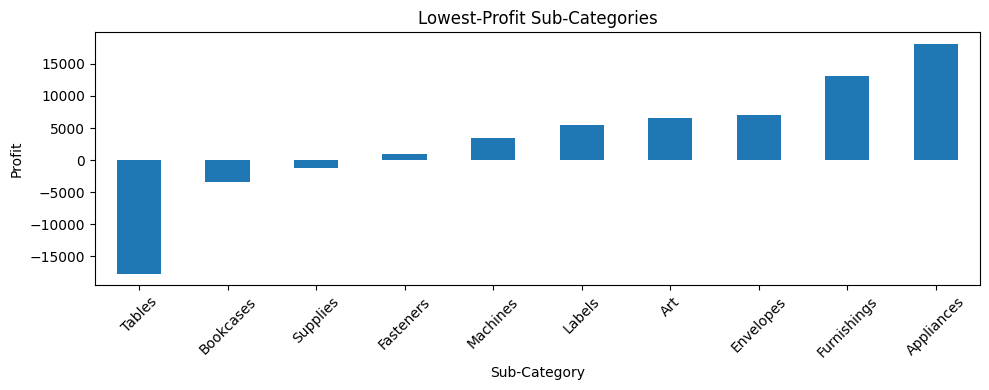

In [82]:
ax = bottom_subcats_by_profit.sort_values("profit").plot(
    x="Sub-Category",
    y="profit",
    kind="bar",
    legend=False,
    figsize=(10, 4),
    title="Lowest-Profit Sub-Categories",
    rot=45
)
ax.set_ylabel("Profit")
plt.tight_layout()
plt.show()

## 10. Concentration — Segment Level

In [83]:
segment_subcat_profit = (
    df_clean.groupby(["Segment", "Sub-Category"], as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        orders=("Order ID", "nunique"),
        avg_discount=("Discount", "mean")
    )
    .sort_values("profit", ascending=True)
)

print("Lowest-profit segment × sub-category combinations")
display(segment_subcat_profit.head(15))

Lowest-profit segment × sub-category combinations


,Segment,Sub-Category,sales,profit,orders,avg_discount
16,Consumer,Tables,"99,933.79","-9,728.04",155,0.27
33,Corporate,Tables,"70,871.72","-4,906.50",101,0.26
4,Consumer,Bookcases,"68,632.73","-4,435.64",128,0.22
50,Home Office,Tables,"36,160.02","-3,090.94",51,0.25
15,Consumer,Supplies,"25,741.50","-1,657.55",98,0.09
42,Home Office,Fasteners,560.05,120.81,44,0.07
49,Home Office,Supplies,"1,496.76",129.53,29,0.06
25,Corporate,Fasteners,783.29,251.90,58,0.12
38,Home Office,Bookcases,"12,241.34",324.63,32,0.16
32,Corporate,Supplies,"19,435.28",338.93,60,0.06


## 11. Loss Concentration — Regional Level

In [84]:
region_subcat_profit = (
    df_clean.groupby(["Region", "Sub-Category"], as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        orders=("Order ID", "nunique"),
        avg_discount=("Discount", "mean")
    )
    .sort_values("profit", ascending=True)
)

print("Lowest-profit region × sub-category combinations")
display(region_subcat_profit.head(15))

Lowest-profit region × sub-category combinations


,Region,Sub-Category,sales,profit,orders,avg_discount
33,East,Tables,"39,139.81","-11,025.38",76,0.37
50,South,Tables,"43,916.19","-4,623.06",49,0.22
9,Central,Furnishings,"15,254.37","-3,906.22",191,0.40
16,Central,Tables,"39,154.97","-3,559.65",68,0.26
1,Central,Appliances,"23,582.03","-2,638.62",119,0.45
4,Central,Bookcases,"24,157.18","-1,997.90",49,0.23
55,West,Bookcases,"36,004.12","-1,646.51",79,0.23
11,Central,Machines,"26,797.38","-1,486.07",20,0.33
45,South,Machines,"53,890.96","-1,438.89",17,0.33
21,East,Bookcases,"43,819.33","-1,167.63",68,0.22


### Purpose:
Localize loss-making patterns geographically.

## 12. Regional and segment performance

In [85]:
region_perf = (
    df_clean.groupby("Region", as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        orders=("Order ID", "nunique"),
        avg_discount=("Discount", "mean")
    )
    .sort_values("sales", ascending=False)
)

segment_perf = (
    df_clean.groupby("Segment", as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        orders=("Order ID", "nunique"),
        avg_discount=("Discount", "mean")
    )
    .sort_values("sales", ascending=False)
)

print("Region performance")
display(region_perf)

print("Segment performance")
display(segment_perf)

Region performance


,Region,sales,profit,orders,avg_discount
3,West,"725,457.82","108,418.45",1611,0.11
1,East,"678,781.24","91,522.78",1401,0.15
0,Central,"501,239.89","39,706.36",1175,0.24
2,South,"391,721.91","46,749.43",822,0.15


Segment performance


,Segment,sales,profit,orders,avg_discount
0,Consumer,"1,161,401.34","134,119.21",2586,0.16
1,Corporate,"706,146.37","91,979.13",1514,0.16
2,Home Office,"429,653.15","60,298.68",909,0.15


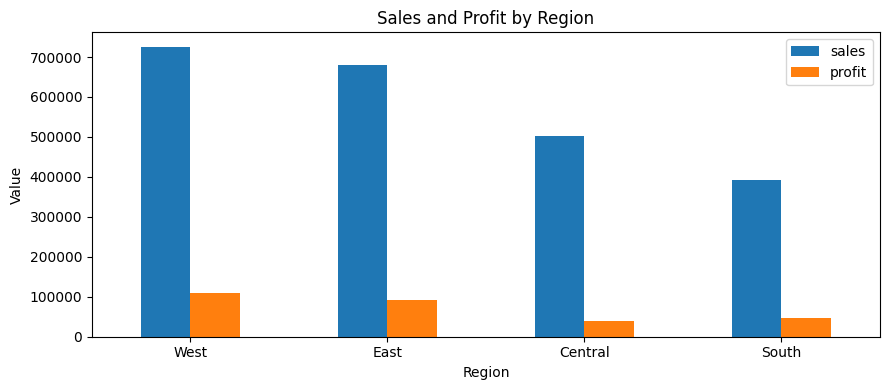

In [86]:
ax = region_perf.plot(
    x="Region",
    y=["sales", "profit"],
    kind="bar",
    figsize=(9, 4),
    title="Sales and Profit by Region",
    rot=0
)
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

## 13. Discount and profitability association

This section is descriptive only.  
Any pattern here is an association, not proof that discounting causes profitability outcomes.

In [87]:
discount_band = pd.cut(
    df_clean["Discount"],
    bins=[-0.001, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=["0%", "0-10%", "10-20%", "20-30%", "30-50%", "50%+"]
)

discount_perf = (
    df_clean.assign(discount_band=discount_band)
    .groupby("discount_band", dropna=False, as_index=False)
    .agg(
        rows=("Row ID", "count"),
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        avg_profit=("Profit", "mean")
    )
)

discount_perf

,discount_band,rows,sales,profit,avg_profit
0,0%,4798,"1,087,908.47","320,987.60",66.90
1,0-10%,94,"54,369.35","9,029.18",96.06
2,10-20%,3709,"792,152.89","91,756.30",24.74
3,20-30%,227,"103,226.65","-10,369.28",-45.68
4,30-50%,310,"195,314.76","-48,447.73",-156.28
5,50%+,856,"64,228.74","-76,559.05",-89.44


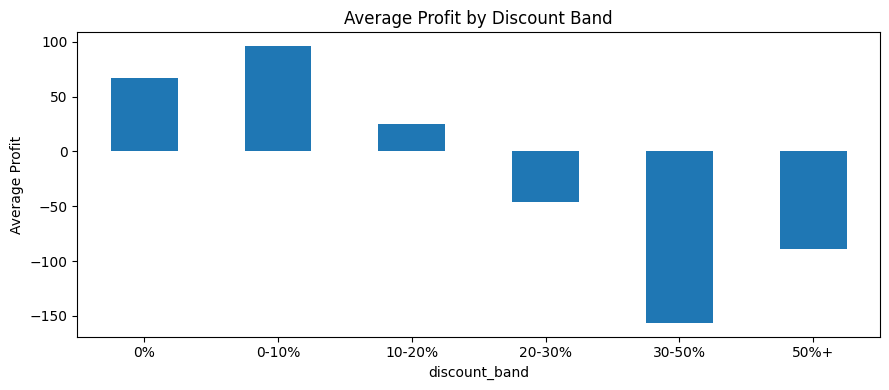

In [88]:
ax = discount_perf.plot(
    x="discount_band",
    y="avg_profit",
    kind="bar",
    legend=False,
    figsize=(9, 4),
    title="Average Profit by Discount Band",
    rot=0
)
ax.set_ylabel("Average Profit")
plt.tight_layout()
plt.show()

In [89]:
corr = df_clean[["Sales", "Quantity", "Discount", "Profit", "ship_delay_days"]].corr(numeric_only=True)
corr

,Sales,Quantity,Discount,Profit,ship_delay_days
Sales,1.00,0.20,-0.03,0.48,-0.01
Quantity,0.20,1.00,0.01,0.07,0.02
Discount,-0.03,0.01,1.00,-0.22,0.00
Profit,0.48,0.07,-0.22,1.00,-0.00
ship_delay_days,-0.01,0.02,0.00,-0.00,1.00


## 14. Revenue Concentration Analysis (60% Descriptive Proxy)

In [90]:
revenue_share_checks = {
    "category_top_share_pct": (
        category_perf["sales"].max() / category_perf["sales"].sum() * 100
    ),
    "top_2_regions_share_pct": (
        region_perf.sort_values("sales", ascending=False).head(2)["sales"].sum()
        / region_perf["sales"].sum() * 100
    ),
    "top_2_segments_share_pct": (
        segment_perf.sort_values("sales", ascending=False).head(2)["sales"].sum()
        / segment_perf["sales"].sum() * 100
    ),
    "top_20pct_subcategories_share_pct": top_20pct_subcats["sales_share_pct"].sum()
}

revenue_share_checks

{'category_top_share_pct': np.float64(36.39882116754926),
 'top_2_regions_share_pct': np.float64(61.12826652505324),
 'top_2_segments_share_pct': np.float64(81.29666604582893),
 'top_20pct_subcategories_share_pct': np.float64(47.417068129503875)}

## Interpretation:

- The largest single category captures 36.40% of total sales.
- The top two regions capture 61.13% of total sales.
- The top two customer segments capture 81.30% of total sales.
- The top 20% of sub-categories capture 47.42% of total sales.

Conclusion:
The 60% threshold is met for some segmentation layers (regions and customer segments), but not for category-top-share or top-20%-sub-category concentration alone.

This should be interpreted as descriptive revenue concentration, not statistical variance explanation.

## Purpose:
Assess whether major segmentation layers capture a majority share of total revenue.

## Interpretation boundary:
This is a concentration-based descriptive proxy, not a formal statistical variance decomposition.

## 15. Time-based descriptive view

In [91]:
monthly_perf = (
    df_clean.groupby("month", as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        orders=("Order ID", "nunique")
    )
    .sort_values("month")
)

monthly_perf.head()

,month,sales,profit,orders
0,2014-01,"14,236.90","2,450.19",32
1,2014-02,"4,519.89",862.31,28
2,2014-03,"55,691.01",498.73,71
3,2014-04,"28,295.35","3,488.84",66
4,2014-05,"23,648.29","2,738.71",69


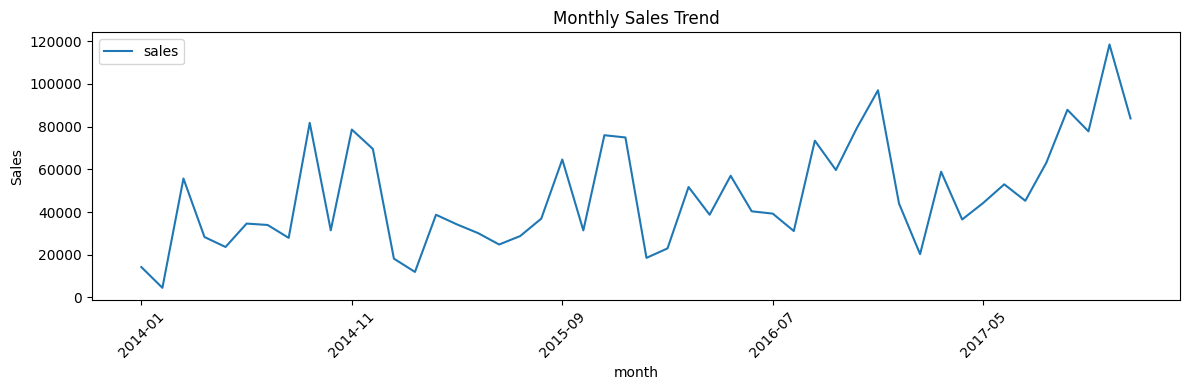

In [92]:
ax = monthly_perf.plot(
    x="month",
    y="sales",
    kind="line",
    figsize=(12, 4),
    title="Monthly Sales Trend"
)
ax.set_ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

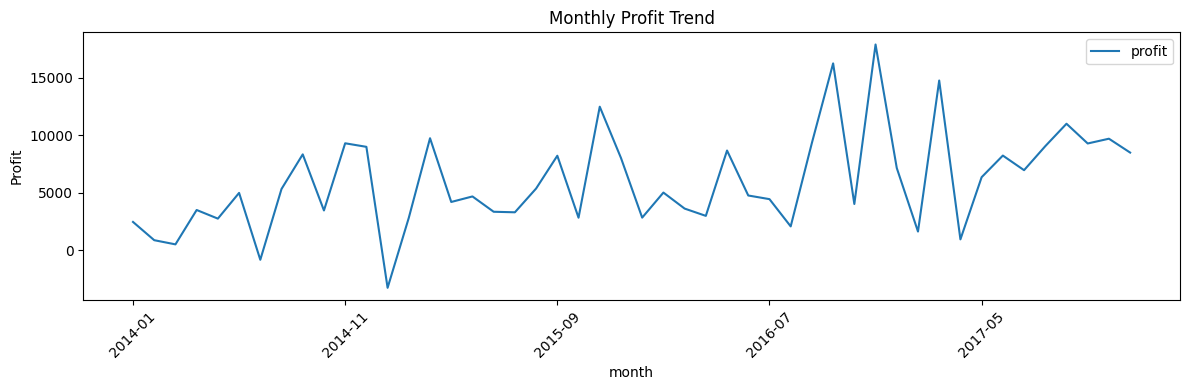

In [93]:
ax = monthly_perf.plot(
    x="month",
    y="profit",
    kind="line",
    figsize=(12, 4),
    title="Monthly Profit Trend"
)
ax.set_ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16. Evidence tables for portfolio reporting

In [94]:
evidence_top = {
    "top_category_by_sales": category_perf.sort_values("sales", ascending=False).iloc[0]["Category"],
    "top_category_sales": float(category_perf.sort_values("sales", ascending=False).iloc[0]["sales"]),
    "top_region_by_sales": region_perf.sort_values("sales", ascending=False).iloc[0]["Region"],
    "lowest_subcategory_by_profit": subcat_perf.sort_values("profit", ascending=True).iloc[0]["Sub-Category"],
    "lowest_subcategory_profit": float(subcat_perf.sort_values("profit", ascending=True).iloc[0]["profit"]),
    "negative_profit_rows": int((df_clean["Profit"] < 0).sum())
}
evidence_top

{'top_category_by_sales': 'Technology',
 'top_category_sales': 836154.033,
 'top_region_by_sales': 'West',
 'lowest_subcategory_by_profit': 'Tables',
 'lowest_subcategory_profit': -17725.4811,
 'negative_profit_rows': 1871}

## 17. What the data supports

Use this section to write evidence-based statements only, for example:
- which category leads in sales
- which region contributes the most profit
- which sub-categories show the largest losses
- whether higher discount bands are associated with lower average profit

Do not write causal statements here.

## 18. What the data does not support

This notebook does **not** support:
- claims that discounts cause losses
- claims that shipping delay causes low profit
- forecasts of future sales
- operational prescriptions without ACT-stage evidence mapping

## 19. Validation checks completed

- Dataset load completed
- Schema inspected
- Missingness profiled
- Duplicate checks run
- Range checks run
- Date parsing validated
- Explicit processing steps documented
- Summary metrics reproduced from processed data

## 20. Final notebook closeout

### Recommended follow-up artifacts
- `01_PREPARE/2026-03-25__superstore__prepare.md`
- `02_PROCESS/2026-03-25__superstore__process_log.md` if you want full transformation logging
- `03_ANALYZE/2026-03-25__superstore__analysis.md`

### Fully addressed
- Revenue and profit leaders by category, region, and segment
- Loss-making concentration at sub-category level
- Reproducible aggregation tables

### Addressed after patch
- Top 20% revenue contributors
- Negative-profit patterns within finer segment layers
- Top 20% revenue contributors identified
- Negative-profit patterns localized within finer segment layers
- 60% success criterion addressed through descriptive revenue concentration proxy (not formal variance decomposition)

### Not claimed
- Causal drivers
- Forecasting
- Action recommendations

### Remaining limitations
- Synthetic/static dataset context
- No external benchmarks
- No inferential design for causality
- No formal sensitivity analysis beyond descriptive checks